In [1]:
# This program predicts the price of Bitcoin for the next 5 days
import pandas as pd
import numpy as np
from sklearn.svm import SVR
import matplotlib.pyplot as plt

In [2]:
# Load and store the data
import sqlalchemy
engine = sqlalchemy.create_engine('sqlite:///BTC-USD_demo.db')
df = pd.read_sql('BTCUSDT', engine)

In [3]:
df

,symbol,Time,Price
0,BTCUSDT,2021-11-18 17:39:35.112,57973.01
1,BTCUSDT,2021-11-18 17:39:37.123,57943.70
2,BTCUSDT,2021-11-18 17:39:39.140,57965.71
3,BTCUSDT,2021-11-18 17:39:41.193,57967.99
4,BTCUSDT,2021-11-18 17:39:43.231,57958.07
...,...,...,...
3759,BTCUSDT,2021-11-18 19:48:53.547,57850.02
3760,BTCUSDT,2021-11-18 19:48:55.657,57871.96
3761,BTCUSDT,2021-11-18 19:48:57.748,57874.86
3762,BTCUSDT,2021-11-18 19:48:59.914,57874.85


In [4]:
prediction_days = 5

In [5]:
# Remvove the Date column

df = df.drop(columns=['symbol', 'Time'])
df[str(prediction_days)+'_Day_Price_Forecast'] = df[["Price"]].shift(-prediction_days)


In [6]:
df.head(7)

,Price,5_Day_Price_Forecast
0,57973.01,57975.40
1,57943.70,57958.07
2,57965.71,57979.28
3,57967.99,57999.96
4,57958.07,57993.01
5,57975.40,58020.18
6,57958.07,58026.49


In [7]:
# Create the independent data set
# Convert the df to numpy array and drop prediction column
X = np.array(df[['Price']])

# Remove the last 5 rows
X = X[:len(df) - prediction_days]

X


array([[57973.01],
       [57943.7 ],
       [57965.71],
       ...,
       [57872.3 ],
       [57872.3 ],
       [57862.02]])

In [8]:
# Create the dependent dataset
# Convert the df to numpy array

y = np.array(df[str(prediction_days)+'_Day_Price_Forecast'])[:-prediction_days]
y

array([57975.4 , 57958.07, 57979.28, ..., 57874.86, 57874.85, 57874.85])

In [9]:
# Split the data into 80% training and 20% testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [10]:
from sklearn.linear_model import LinearRegression

# Create and train the SVM by Regression using radial basis function

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [11]:
# Test the model
svm_prediction = model.predict(x_test)
print(svm_prediction)
print(y_test)


[57868.48366898 57805.14769857 58038.047189   58223.40504229
 57582.46048889 58044.59098056 57905.67421766 57789.65081038
 57816.3514629  57978.44911165 57838.65984321 57960.1859843
 57710.22306164 58185.13377651 58076.74479271 57615.58595495
 57897.46473371 57953.38440702 58227.9063777  58188.12805689
 57793.5175963  57606.80141052 57736.04129378 57747.27480263
 58122.93801221 57763.93172659 57585.81170336 57903.45329447
 58154.16974464 57578.10787603 58152.56354126 57921.69659214
 57650.07966832 57733.63198871 57916.80857815 57744.39950027
 57809.51022627 57641.75120634 57568.92673817 57779.00227684
 57952.31360476 57927.56617487 57934.43715601 58024.67207565
 57721.78376006 58034.9339306  58032.70309257 58152.73209347
 57926.91179572 57758.06214386 57837.91623053 57957.84608308
 57701.54758041 57759.0734571  57753.05515183 57651.9337426
 58307.0465962  57819.59361417 58158.93878061 58210.21831082
 58000.72774745 57701.56741008 58098.15092298 58064.22235523
 57526.16405183 58198.7468

In [12]:
model.score(x_test, y_test)

0.9836276470205116

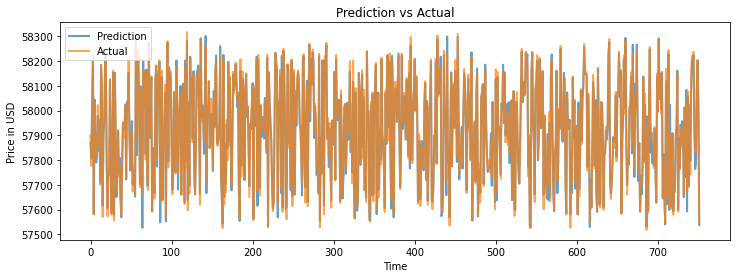

In [13]:
plt.figure(figsize=(12,4))
plt.plot(svm_prediction, label='Prediction', lw=2, alpha=.7)
plt.plot(y_test, label='Actual', lw=2, alpha=.7)
plt.title('Prediction vs Actual')
plt.ylabel('Price in USD')
plt.xlabel('Time')
plt.legend()
plt.show()

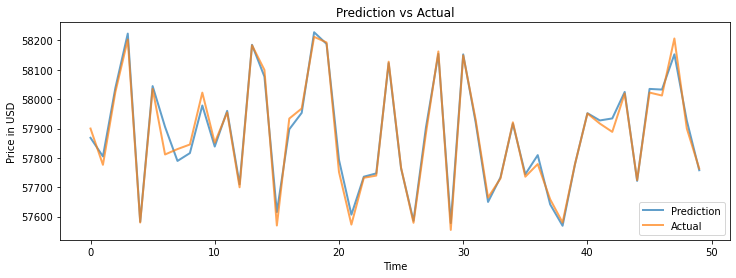

In [14]:
plt.figure(figsize=(12,4))
plt.plot(svm_prediction[:50], label='Prediction', lw=2, alpha=.7)
plt.plot(y_test[:50], label='Actual', lw=2, alpha=.7)
plt.title('Prediction vs Actual')
plt.ylabel('Price in USD')
plt.xlabel('Time')
plt.legend()
plt.show()